# Foundation Model Tutorial
## Frontiers in Foundation Models

本 Notebook 对应 Slides: **05_Frontiers in foundation.pdf**

这份配套笔记只抓 Slides 里最核心、最适合“动手理解”的部分：

1. Token embedding / positional embedding
2. Scaled dot-product attention / causal mask
3. Multi-head attention 与 Transformer block
4. Self-supervised pretraining 的两种代表目标：CLM 与 MLM
5. 一个从零写的 tiny decoder-only LM
6. MoE 与 DPO 的极简实现
7. Hugging Face 预训练模型的直接推理
8. Masked generation / discrete diffusion / LLaDA 的直觉补充

实现策略：

- **尽量少依赖 `torch.nn` 封装**，核心机制都手写出来
- 主要使用 `torch` 的张量、自动求导、优化器这些基础能力
- 只在一小节里给出 `torch.nn.MultiheadAttention` 的对照版本，帮助把“原理实现”和“工程实现”对上

---

### 读完后你应该能回答

- Attention 本质上为什么是“按相关性做加权平均”？
- Decoder-only 模型为什么一定要加 causal mask？
- Transformer block 到底只是哪些基础算子拼起来的？
- GPT 类的 CLM 和 BERT 类的 MLM，训练样本是怎么构造出来的？
- MoE 和 DPO 在 foundation model 训练链条里各自解决什么问题？
- 理解了原理之后，怎样直接调用 Hugging Face 上的现成 foundation model 做推理？
- 为什么 masked generation、discrete diffusion、LLaDA 会被看作后续很重要的生成路线？

In [1]:
import math
import random

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

torch.set_printoptions(precision=3, sci_mode=False)
plt.style.use('seaborn-v0_8-whitegrid')

---
## 1. 从一个极小语料开始

Slides 里反复强调 foundation model 的两件事：

- **架构**：Transformer 为主
- **训练范式**：self-supervised pretraining 为主

为了把代码尽量压到最小，我们只用几句和课程主题相关的 toy corpus。后面所有 embedding、attention、LM objective 都基于它展开。

In [2]:
corpus = [
    'transformers use attention to mix information across tokens',
    'foundation models scale with data and compute',
    'masked language modeling predicts hidden tokens',
    'causal language modeling predicts next tokens',
    'mixture of experts activates only a few experts',
    'alignment tunes models with preference data',
    'self supervised learning turns data into labels',
    'positional embeddings encode token order'
]

special_tokens = ['<pad>', '<bos>', '<eos>', '<mask>']
vocab = special_tokens + sorted({token for sent in corpus for token in sent.split()})
stoi = {token: i for i, token in enumerate(vocab)}
itos = {i: token for token, i in stoi.items()}

PAD = stoi['<pad>']
BOS = stoi['<bos>']
EOS = stoi['<eos>']
MASK = stoi['<mask>']


def encode(text):
    return [stoi[token] for token in text.split()]


def decode(ids):
    return ' '.join(itos[i] for i in ids)


example_text = corpus[0]
example_ids = encode(example_text)

print('vocab size =', len(vocab))
print('example text =', example_text)
print('encoded ids   =', example_ids)
print('decoded text  =', decode(example_ids))

vocab size = 47
example text = transformers use attention to mix information across tokens
encoded ids   = [42, 45, 9, 39, 25, 19, 5, 41]
decoded text  = transformers use attention to mix information across tokens


---
## 2. Token Embedding + Positional Encoding

Slides 第 13-14 页的意思很直接：

- token embedding 负责“这个词本身是什么”
- positional embedding 负责“它出现在序列的哪里”

如果只有词向量，没有位置信息，那么模型看到 `A B C` 和 `C B A` 的 token 集合几乎一样，很难区分顺序。

最常见的写法是：对第 $i$ 个 token，先查表得到词向量 $e_i$，再加上位置向量 $p_i$：

$$
x_i = e_i + p_i
$$

把整句堆起来，如果 token embedding 矩阵记为 $E$、position embedding 记为 $P$，则输入表示可以写成：

$$
X = E[\text{tokens}] + P[\text{positions}]
$$

token embedding shape       = torch.Size([8, 8])
token + learned pos shape   = torch.Size([8, 8])
first token vector (before) = tensor([ 0.018,  0.004,  0.016, -0.001,  0.011, -0.014, -0.010,  0.001])
first token vector (after)  = tensor([    -0.007,      0.021,     -0.013,     -0.015,      0.005,      0.010,
             0.019,     -0.000])


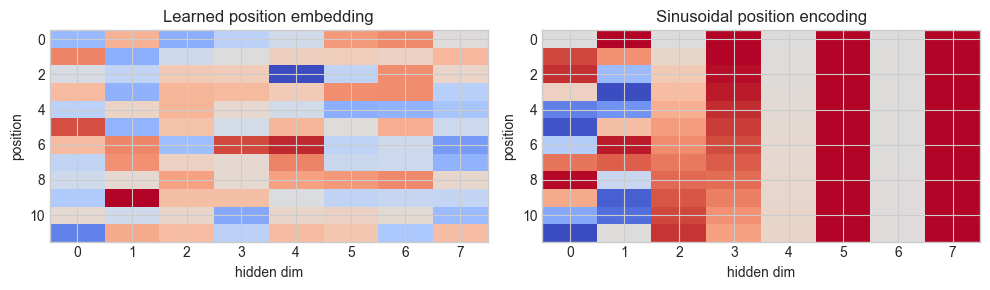

In [3]:
d_model = 8
max_len = 12

token_embedding = torch.randn(len(vocab), d_model) * 0.02
learned_position = torch.randn(max_len, d_model) * 0.02


def sinusoidal_position_encoding(max_len, d_model):
    pe = torch.zeros(max_len, d_model)
    positions = torch.arange(max_len, dtype=torch.float32).unsqueeze(1)
    div_term = torch.exp(
        torch.arange(0, d_model, 2, dtype=torch.float32) * (-math.log(10000.0) / d_model)
    )
    pe[:, 0::2] = torch.sin(positions * div_term)
    pe[:, 1::2] = torch.cos(positions * div_term)
    return pe


sinusoidal_pe = sinusoidal_position_encoding(max_len, d_model)
example_tensor = torch.tensor(example_ids)
example_embed = token_embedding[example_tensor]
example_with_pos = example_embed + learned_position[: len(example_ids)]

print('token embedding shape       =', example_embed.shape)
print('token + learned pos shape   =', example_with_pos.shape)
print('first token vector (before) =', example_embed[0])
print('first token vector (after)  =', example_with_pos[0])

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].imshow(learned_position.numpy(), aspect='auto', cmap='coolwarm')
axes[0].set_title('Learned position embedding')
axes[0].set_xlabel('hidden dim')
axes[0].set_ylabel('position')

axes[1].imshow(sinusoidal_pe.numpy(), aspect='auto', cmap='coolwarm')
axes[1].set_title('Sinusoidal position encoding')
axes[1].set_xlabel('hidden dim')
axes[1].set_ylabel('position')
plt.tight_layout()
plt.show()

### 更深一层：Positional Encoding 到底解决了什么？

一个更本质的说法是：**如果没有位置信息，self-attention 对 token 顺序是置换等变的（permutation equivariant）**。

设 $\Pi$ 是一个对序列位置做重排的置换矩阵。如果输入只有 token embedding，没有 position term，那么 attention 满足：

$$
\operatorname{Attn}(\Pi X) = \Pi \, \operatorname{Attn}(X)
$$

这句话的意思不是“模型完全看不见内容”，而是：**它看得见 token 是什么，却不知道谁在前、谁在后**。因此 `A B C` 和 `C B A` 会被当成“同一组 token 的不同排列”，模型本身没有理由偏好其中某一种顺序。

加上位置编码以后，输入变成 $X = E + P$，其中 $P$ 不再随着 token 身份一起被任意重排，于是这种对顺序的对称性被打破了。也可以把 positional encoding 理解成一种 **symmetry breaking**：它把“无序集合”变回了“有序序列”。

对于 sinusoidal encoding，经典 Transformer 用的是：

$$
\mathrm{PE}(\text{pos}, 2k) = \sin\!\left(\frac{\text{pos}}{10000^{2k/d}}\right),
\qquad
\mathrm{PE}(\text{pos}, 2k+1) = \cos\!\left(\frac{\text{pos}}{10000^{2k/d}}\right)
$$

这里每一对维度对应一个不同频率的正弦波。更低频的维度变化慢，适合表示长程结构；更高频的维度变化快，适合区分近邻位置。于是一个位置不是由单一标号表示，而是由**多尺度频率基底**共同编码。

它的深层好处在于：相对位移 $\Delta$ 可以通过三角恒等式从 $\text{pos}$ 和 $\text{pos}+\Delta$ 的编码里线性地恢复出来。例如：

$$
\sin(a+b) = \sin a \cos b + \cos a \sin b
$$

所以位置从 $\text{pos}$ 平移到 $\text{pos}+\Delta$，在每个频率子空间里都像做了一个小旋转。这也是为什么后来的 **RoPE** 可以理解成“直接在 query/key 的二维子空间里做位置相关旋转”，而 relative position bias 则是另一种更直接把“距离 $i-j$”写进 attention score 的办法。

从建模角度看，可以把几种方法这样理解：

- learned absolute embedding：告诉模型“我是第 17 个位置”
- sinusoidal absolute embedding：用连续、多频率基底表示“我是第 17 个位置”
- relative / RoPE：更强调“我和你之间差了多少位置”

而语言理解里真正重要的，往往不是绝对位置本身，而是**相对顺序和相对距离**。这也是现代大模型里大家越来越重视 relative position、RoPE、ALiBi 这类设计的原因。

---
## 3. Self-Attention 从零写

Slides 第 15-17 页讲的是 attention 的核心直觉：

- 每个 token 生成一个 query / key / value
- `query · key` 决定“我该看谁”
- softmax 把相关性变成概率分布
- 最后对所有 value 做加权平均

如果把一层输入记成矩阵 $X \in \mathbb{R}^{L \times d}$，那么 query、key、value 的线性投影是：

$$
Q = XW_Q, \qquad K = XW_K, \qquad V = XW_V
$$

注意力分数、权重和输出分别是：

$$
S = \frac{QK^\top}{\sqrt{d_k}}, \qquad
A = \operatorname{softmax}(S), \qquad
Y = AV
$$

这正对应 Slides 里的直觉：attention 本质上就是“按相关性做加权平均”。

下面先用 `numpy` 写一个最小版本，确保公式和实现是一一对应的。

attention output shape = (8, 8)
attention row sums     = [1. 1. 1. 1. 1. 1. 1. 1.]


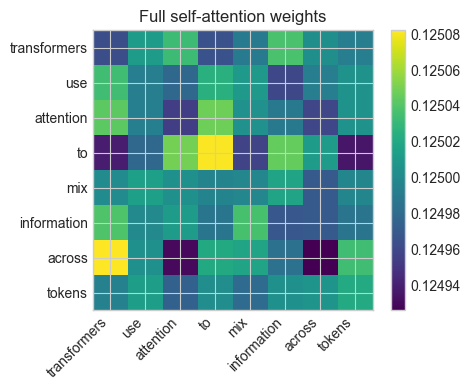

In [4]:
def softmax_np(x, axis=-1):
    x = x - np.max(x, axis=axis, keepdims=True)
    exp_x = np.exp(x)
    return exp_x / exp_x.sum(axis=axis, keepdims=True)


def scaled_dot_product_attention_np(q, k, v, mask=None):
    scores = q @ k.T / np.sqrt(q.shape[-1])
    if mask is not None:
        scores = np.where(mask, scores, -1e9)
    weights = softmax_np(scores, axis=-1)
    out = weights @ v
    return out, weights, scores


x_np = example_with_pos.numpy()
dim = x_np.shape[-1]
rng = np.random.default_rng(SEED)
Wq = rng.standard_normal((dim, dim)) / np.sqrt(dim)
Wk = rng.standard_normal((dim, dim)) / np.sqrt(dim)
Wv = rng.standard_normal((dim, dim)) / np.sqrt(dim)

q = x_np @ Wq
k = x_np @ Wk
v = x_np @ Wv

attn_out, attn_weights, attn_scores = scaled_dot_product_attention_np(q, k, v)
word_labels = example_text.split()

print('attention output shape =', attn_out.shape)
print('attention row sums     =', attn_weights.sum(axis=-1))

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(attn_weights, cmap='viridis')
ax.set_xticks(range(len(word_labels)), word_labels, rotation=45, ha='right')
ax.set_yticks(range(len(word_labels)), word_labels)
ax.set_title('Full self-attention weights')
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

---
## 4. 为什么 Decoder 必须要 Causal Mask

Decoder-only Transformer 做 next-token prediction 时，第 `t` 个位置只能看见 `<= t` 的 token。

否则训练时模型会直接偷看答案，目标就失真了。

数学上，就是在 attention score 上加一个上三角 mask：

$$
M_{ij} =
\begin{cases}
0, & j \le i \\
-\infty, & j > i
\end{cases}
$$

于是 decoder attention 变成：

$$
A = \operatorname{softmax}\!\left(\frac{QK^\top + M}{\sqrt{d_k}}\right)
$$

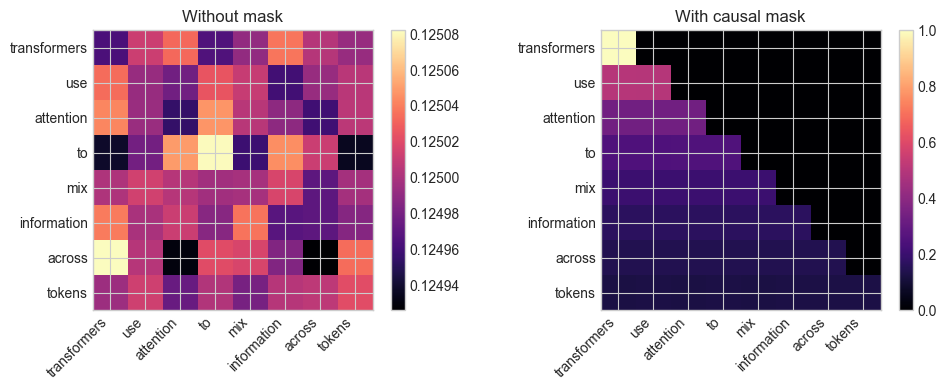

In [5]:
L = len(word_labels)
causal_mask = np.tril(np.ones((L, L), dtype=bool))
causal_out, causal_weights, _ = scaled_dot_product_attention_np(q, k, v, mask=causal_mask)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, weights, title in [
    (axes[0], attn_weights, 'Without mask'),
    (axes[1], causal_weights, 'With causal mask')
]:
    im = ax.imshow(weights, cmap='magma')
    ax.set_xticks(range(L), word_labels, rotation=45, ha='right')
    ax.set_yticks(range(L), word_labels)
    ax.set_title(title)
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.tight_layout()
plt.show()

---
## 5. Multi-Head Attention 与 Transformer Block

Slides 第 18-21 页把 attention 扩展成完整的 Transformer block：

1. Multi-head attention
2. Residual connection
3. LayerNorm
4. Feed-forward network

多头注意力就是把 hidden dimension 切成多个 head，分别做 attention：

$$
\text{head}_h = \operatorname{Attention}(XW_Q^{(h)}, XW_K^{(h)}, XW_V^{(h)})
$$

$$
\operatorname{MHA}(X) = \operatorname{Concat}(\text{head}_1, \ldots, \text{head}_H) W_O
$$

而这份 notebook 里的 block 用的是 pre-LN 结构，可以写成：

$$
\tilde{X} = X + \operatorname{MHA}(\operatorname{LN}(X))
$$

$$
Y = \tilde{X} + \operatorname{FFN}(\operatorname{LN}(\tilde{X}))
$$

其中前馈网络通常是两层 MLP：

$$
\operatorname{FFN}(x) = W_2 \, \phi(W_1 x + b_1) + b_2
$$

这里全部用基础张量运算手写，不调用 `nn.MultiheadAttention`。

input shape  = torch.Size([1, 8, 16])
output shape = torch.Size([1, 8, 16])
attn shape   = torch.Size([1, 4, 8, 8])


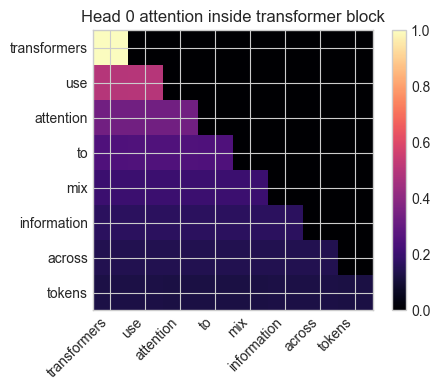

In [6]:
def softmax_torch(x, dim=-1):
    x = x - x.amax(dim=dim, keepdim=True)
    exp_x = torch.exp(x)
    return exp_x / exp_x.sum(dim=dim, keepdim=True)


def linear(x, w, b=None):
    y = x @ w
    return y if b is None else y + b


def split_heads(x, num_heads):
    batch, seq_len, d_model = x.shape
    d_head = d_model // num_heads
    return x.view(batch, seq_len, num_heads, d_head).permute(0, 2, 1, 3)


def combine_heads(x):
    batch, num_heads, seq_len, d_head = x.shape
    return x.permute(0, 2, 1, 3).contiguous().view(batch, seq_len, num_heads * d_head)


def layer_norm(x, gain, bias, eps=1e-5):
    mean = x.mean(dim=-1, keepdim=True)
    var = ((x - mean) ** 2).mean(dim=-1, keepdim=True)
    return gain * (x - mean) / torch.sqrt(var + eps) + bias


def gelu(x):
    return 0.5 * x * (1.0 + torch.tanh(math.sqrt(2.0 / math.pi) * (x + 0.044715 * x ** 3)))


def init_block_params(d_model, d_ff, scale=0.02):
    return {
        'Wq': torch.randn(d_model, d_model) * scale,
        'Wk': torch.randn(d_model, d_model) * scale,
        'Wv': torch.randn(d_model, d_model) * scale,
        'Wo': torch.randn(d_model, d_model) * scale,
        'W1': torch.randn(d_model, d_ff) * scale,
        'b1': torch.zeros(d_ff),
        'W2': torch.randn(d_ff, d_model) * scale,
        'b2': torch.zeros(d_model),
        'ln1_g': torch.ones(d_model),
        'ln1_b': torch.zeros(d_model),
        'ln2_g': torch.ones(d_model),
        'ln2_b': torch.zeros(d_model),
    }


def multi_head_attention(x, params, num_heads, mask=None):
    q = split_heads(linear(x, params['Wq']), num_heads)
    k = split_heads(linear(x, params['Wk']), num_heads)
    v = split_heads(linear(x, params['Wv']), num_heads)

    scores = q @ k.transpose(-1, -2) / math.sqrt(q.shape[-1])
    if mask is not None:
        scores = scores.masked_fill(~mask, -1e9)

    weights = softmax_torch(scores, dim=-1)
    out = weights @ v
    out = combine_heads(out)
    out = linear(out, params['Wo'])
    return out, weights


def feed_forward(x, params):
    hidden = gelu(linear(x, params['W1'], params['b1']))
    return linear(hidden, params['W2'], params['b2'])


def transformer_block(x, params, num_heads, mask=None):
    h = layer_norm(x, params['ln1_g'], params['ln1_b'])
    attn_out, attn_weights = multi_head_attention(h, params, num_heads, mask)
    x = x + attn_out

    h = layer_norm(x, params['ln2_g'], params['ln2_b'])
    x = x + feed_forward(h, params)
    return x, attn_weights


d_model_big = 16
num_heads = 4
d_ff = 32
block_params = init_block_params(d_model_big, d_ff)

big_token_embedding = torch.randn(len(vocab), d_model_big) * 0.02
big_position_encoding = sinusoidal_position_encoding(max_len, d_model_big)
example_idx = torch.tensor(example_ids).unsqueeze(0)
x = big_token_embedding[example_idx] + big_position_encoding[: example_idx.shape[1]].unsqueeze(0)
mask = torch.tril(torch.ones(example_idx.shape[1], example_idx.shape[1], dtype=torch.bool)).view(1, 1, example_idx.shape[1], example_idx.shape[1])

block_out, block_weights = transformer_block(x, block_params, num_heads=num_heads, mask=mask)
print('input shape  =', x.shape)
print('output shape =', block_out.shape)
print('attn shape   =', block_weights.shape)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(block_weights[0, 0].detach().numpy(), cmap='magma')
ax.set_xticks(range(len(word_labels)), word_labels, rotation=45, ha='right')
ax.set_yticks(range(len(word_labels)), word_labels)
ax.set_title('Head 0 attention inside transformer block')
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

### 工程对照：`torch.nn.MultiheadAttention`

上面是“把结构摊开”的写法。实际工程里通常不会手写这么多矩阵运算，而是直接调用封装好的模块。

但你应该把它理解为：**封装只是把刚才那一堆基础算子包起来了**。

In [7]:
mha = nn.MultiheadAttention(embed_dim=d_model_big, num_heads=num_heads, batch_first=True)
L = x.shape[1]
causal_attn_mask = torch.triu(torch.full((L, L), float('-inf')), diagonal=1)

nn_out, nn_weights = mha(
    x, x, x,
    attn_mask=causal_attn_mask,
    need_weights=True,
    average_attn_weights=False,
)

print('nn.MultiheadAttention output shape =', nn_out.shape)
print('nn.MultiheadAttention weight shape =', nn_weights.shape)

nn.MultiheadAttention output shape = torch.Size([1, 8, 16])
nn.MultiheadAttention weight shape = torch.Size([1, 4, 8, 8])


---
## 6. 两类最重要的自监督目标：CLM 与 MLM

Slides 后半段的主线是：foundation models 的关键不仅是 Transformer，还包括**怎样构造 pretraining objective**。

这里先把训练数据的构造过程写清楚：

- **CLM (causal language modeling)**：给前缀，预测下一个 token
- **MLM (masked language modeling)**：把部分 token 挖掉，让模型补回去

两类目标最紧凑的数学写法分别是：

$$
\mathcal{L}_{\text{CLM}} = - \sum_{t=1}^{T} \log p_{\theta}(x_t \mid x_{<t})
$$

$$
\mathcal{L}_{\text{MLM}} = - \sum_{i \in \mathcal{M}} \log p_{\theta}(x_i \mid x_{\setminus \mathcal{M}})
$$

其中 $\mathcal{M}$ 是被 mask 的位置集合。CLM 强调“左到右”，MLM 强调“从残缺输入恢复被遮住的位置”。

In [8]:
def ids_to_tokens(ids):
    return [itos[i] if i >= 0 else '<ignore>' for i in ids]


def make_causal_examples(sentences, block_size):
    xs, ys = [], []
    for sentence in sentences:
        seq = [BOS] + encode(sentence) + [EOS]
        n_chunks = max(1, len(seq) - block_size)
        for start in range(n_chunks):
            chunk = seq[start : start + block_size + 1]
            if len(chunk) < block_size + 1:
                chunk = chunk + [PAD] * (block_size + 1 - len(chunk))
            xs.append(chunk[:-1])
            ys.append(chunk[1:])
    return torch.tensor(xs), torch.tensor(ys)


def make_mlm_example(sentence, mask_prob=0.3, span_len=1):
    ids = [BOS] + encode(sentence) + [EOS]
    x = ids.copy()
    labels = [-100] * len(ids)

    candidate_positions = list(range(1, len(ids) - 1))
    random.shuffle(candidate_positions)
    n_to_mask = max(1, int((len(ids) - 2) * mask_prob))
    masked = 0

    for start in candidate_positions:
        if masked >= n_to_mask:
            break
        for pos in range(start, min(start + span_len, len(ids) - 1)):
            if labels[pos] != -100:
                continue
            labels[pos] = ids[pos]
            x[pos] = MASK
            masked += 1
            if masked >= n_to_mask:
                break

    return x, labels


X_clm, Y_clm = make_causal_examples(corpus, block_size=6)
mlm_input, mlm_labels = make_mlm_example(corpus[2], mask_prob=0.4, span_len=2)

print('CLM input tokens :', ids_to_tokens(X_clm[0].tolist()))
print('CLM target tokens:', ids_to_tokens(Y_clm[0].tolist()))
print()
print('MLM input tokens :', ids_to_tokens(mlm_input))
print('MLM labels       :', ids_to_tokens(mlm_labels))

CLM input tokens : ['<bos>', 'transformers', 'use', 'attention', 'to', 'mix']
CLM target tokens: ['transformers', 'use', 'attention', 'to', 'mix', 'information']

MLM input tokens : ['<bos>', 'masked', 'language', 'modeling', '<mask>', '<mask>', 'tokens', '<eos>']
MLM labels       : ['<ignore>', '<ignore>', '<ignore>', '<ignore>', 'predicts', 'hidden', '<ignore>', '<ignore>']


---
## 7. 一个从零写的 Tiny Decoder-Only LM

下面我们真的训练一个小模型。结构非常简单：

1. token embedding + position embedding
2. 1 个 Transformer block
3. 输出到词表 logits
4. 用 CLM 目标训练

如果最后一层 hidden state 记为 $h_t$，输出词表 logits 可以写成：

$$
\text{logits}_t = h_t W_{\text{out}} + b_{\text{out}}
$$

再通过 softmax 得到下一个 token 的条件分布：

$$
p_{\theta}(x_{t+1} \mid x_{\le t}) = \operatorname{softmax}(\text{logits}_t)
$$

训练时最小化的就是 cross-entropy，也就是负对数似然：

$$
\mathcal{L} = - \frac{1}{T} \sum_{t=1}^{T} \log p_{\theta}(y_t \mid x_{\le t})
$$

重点不是效果，而是把 GPT 类模型最关键的 forward / loss / generate 流程看清楚。

In [9]:
block_size = 6
X_train, Y_train = make_causal_examples(corpus, block_size=block_size)


def make_parameter(*shape, scale=0.02):
    return (torch.randn(*shape) * scale).requires_grad_()


def init_decoder_params(vocab_size, block_size, d_model=24, d_ff=48):
    return {
        'token_emb': make_parameter(vocab_size, d_model),
        'pos_emb': make_parameter(block_size, d_model),
        'Wq': make_parameter(d_model, d_model),
        'Wk': make_parameter(d_model, d_model),
        'Wv': make_parameter(d_model, d_model),
        'Wo': make_parameter(d_model, d_model),
        'W1': make_parameter(d_model, d_ff),
        'b1': torch.zeros(d_ff, requires_grad=True),
        'W2': make_parameter(d_ff, d_model),
        'b2': torch.zeros(d_model, requires_grad=True),
        'ln1_g': torch.ones(d_model, requires_grad=True),
        'ln1_b': torch.zeros(d_model, requires_grad=True),
        'ln2_g': torch.ones(d_model, requires_grad=True),
        'ln2_b': torch.zeros(d_model, requires_grad=True),
        'lnf_g': torch.ones(d_model, requires_grad=True),
        'lnf_b': torch.zeros(d_model, requires_grad=True),
        'out_w': make_parameter(d_model, vocab_size),
        'out_b': torch.zeros(vocab_size, requires_grad=True),
    }


def cross_entropy_from_logits(logits, targets):
    log_probs = logits - torch.logsumexp(logits, dim=-1, keepdim=True)
    picked = log_probs.gather(-1, targets.unsqueeze(-1)).squeeze(-1)
    valid = (targets != PAD).float()
    return -(picked * valid).sum() / valid.sum().clamp_min(1.0)


def decoder_forward(idx, params, num_heads=4):
    batch, seq_len = idx.shape
    x = params['token_emb'][idx] + params['pos_emb'][:seq_len].unsqueeze(0)

    mask = torch.tril(torch.ones(seq_len, seq_len, dtype=torch.bool)).view(1, 1, seq_len, seq_len)
    block_params = {
        'Wq': params['Wq'], 'Wk': params['Wk'], 'Wv': params['Wv'], 'Wo': params['Wo'],
        'W1': params['W1'], 'b1': params['b1'], 'W2': params['W2'], 'b2': params['b2'],
        'ln1_g': params['ln1_g'], 'ln1_b': params['ln1_b'],
        'ln2_g': params['ln2_g'], 'ln2_b': params['ln2_b'],
    }
    x, attn_weights = transformer_block(x, block_params, num_heads=num_heads, mask=mask)
    x = layer_norm(x, params['lnf_g'], params['lnf_b'])
    logits = linear(x, params['out_w'], params['out_b'])
    return logits, attn_weights


print('training set shape:', X_train.shape, Y_train.shape)

training set shape: torch.Size([21, 6]) torch.Size([21, 6])


step   0 | loss = 3.8488
step  50 | loss = 0.1605
step 100 | loss = 0.1362
step 150 | loss = 0.1347
step 200 | loss = 0.1339
step 250 | loss = 0.1334


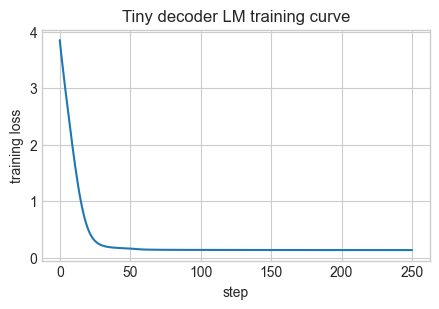

generated tokens = ['<bos>', 'foundation', 'models', 'scale', 'with', 'data', 'and', 'compute', '<eos>']
generated text   = <bos> foundation models scale with data and compute <eos>


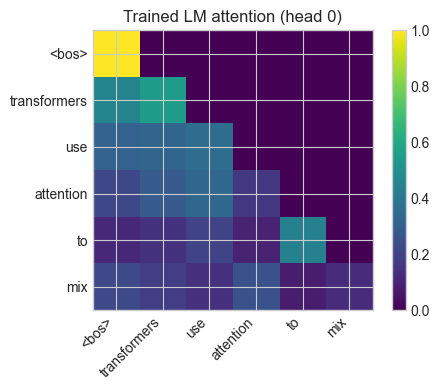

In [10]:
decoder_params = init_decoder_params(len(vocab), block_size=block_size, d_model=24, d_ff=48)
optimizer = torch.optim.Adam(list(decoder_params.values()), lr=1e-2)
loss_history = []

for step in range(251):
    logits, attn_weights = decoder_forward(X_train, decoder_params, num_heads=4)
    loss = cross_entropy_from_logits(logits, Y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())
    if step % 50 == 0:
        print(f'step {step:3d} | loss = {loss.item():.4f}')


def generate(prompt_tokens, max_new_tokens=6):
    ids = [BOS] + [stoi[token] for token in prompt_tokens]
    for _ in range(max_new_tokens):
        window = ids[-block_size:]
        if len(window) < block_size:
            window = [PAD] * (block_size - len(window)) + window

        x = torch.tensor(window).unsqueeze(0)
        logits, _ = decoder_forward(x, decoder_params, num_heads=4)
        next_id = int(torch.argmax(logits[0, -1]).item())
        ids.append(next_id)
        if next_id == EOS:
            break
    return ids


plt.figure(figsize=(5, 3))
plt.plot(loss_history)
plt.xlabel('step')
plt.ylabel('training loss')
plt.title('Tiny decoder LM training curve')
plt.show()

generated_ids = generate(['foundation', 'models'])
print('generated tokens =', ids_to_tokens(generated_ids))
print('generated text   =', decode([i for i in generated_ids if i != PAD]))

sample_logits, sample_attn = decoder_forward(X_train[:1], decoder_params, num_heads=4)
sample_tokens = ids_to_tokens(X_train[0].tolist())

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(sample_attn[0, 0].detach().numpy(), cmap='viridis')
ax.set_xticks(range(len(sample_tokens)), sample_tokens, rotation=45, ha='right')
ax.set_yticks(range(len(sample_tokens)), sample_tokens)
ax.set_title('Trained LM attention (head 0)')
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

---
## 8. MoE: 只激活少数专家

Slides 里把 MoE 放在“更聪明地扩展参数量”这一节。核心思想其实很简单：

- 不是所有 token 都走同一个 MLP
- 先用 router 给 token 选专家
- 每个 token 只激活 top-k 个专家

如果一个 token 的表示记成 $x$，router 的 gating distribution 可以写成：

$$
g(x) = \operatorname{softmax}(x W_{\text{gate}})
$$

只取 top-$k$ 专家后，输出是稀疏加权和：

$$
y = \sum_{e \in \operatorname{TopK}(g)} g_e(x) \, E_e(x)
$$

这里的关键不是“有很多专家”，而是“每个 token 只走很少几个专家”，这样总参数量可以很大，但单次计算量不会线性爆炸。

下面是一个不依赖任何高级框架模块的极简版本。

moe input shape  = torch.Size([8, 16])
moe output shape = torch.Size([8, 16])
router probs for token 0 = tensor([0.104, 0.068, 0.699, 0.129])
expert load = tensor([0., 0., 8., 8.])


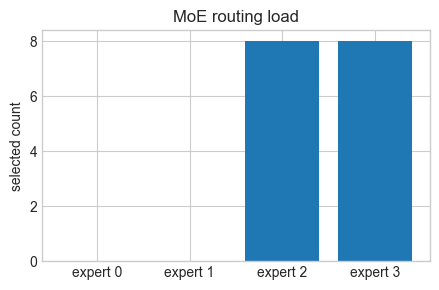

In [11]:
def init_expert(d_model, d_hidden, scale=0.1):
    return {
        'W1': torch.randn(d_model, d_hidden) * scale,
        'b1': torch.zeros(d_hidden),
        'W2': torch.randn(d_hidden, d_model) * scale,
        'b2': torch.zeros(d_model),
    }


def expert_mlp(x, expert):
    hidden = torch.tanh(linear(x, expert['W1'], expert['b1']))
    return linear(hidden, expert['W2'], expert['b2'])


def moe_layer(x, gate_w, experts, top_k=2):
    gate_probs = torch.softmax(x @ gate_w, dim=-1)
    top_values, top_indices = gate_probs.topk(top_k, dim=-1)
    top_values = top_values / top_values.sum(dim=-1, keepdim=True)

    outputs = []
    load = torch.zeros(len(experts))
    for token_idx in range(x.shape[0]):
        y = torch.zeros_like(x[token_idx])
        for weight, expert_idx in zip(top_values[token_idx], top_indices[token_idx]):
            load[int(expert_idx)] += 1
            y = y + weight * expert_mlp(x[token_idx], experts[int(expert_idx)])
        outputs.append(y)

    return torch.stack(outputs), gate_probs, load


moe_input = block_out[0].detach()
experts = [init_expert(d_model_big, 24) for _ in range(4)]
gate_w = torch.randn(d_model_big, len(experts)) / math.sqrt(d_model_big)
moe_out, gate_probs, load = moe_layer(moe_input, gate_w, experts, top_k=2)

print('moe input shape  =', moe_input.shape)
print('moe output shape =', moe_out.shape)
print('router probs for token 0 =', gate_probs[0])
print('expert load =', load)

plt.figure(figsize=(5, 3))
plt.bar(range(len(experts)), load.numpy())
plt.xticks(range(len(experts)), [f'expert {i}' for i in range(len(experts))])
plt.ylabel('selected count')
plt.title('MoE routing load')
plt.show()

---
## 9. DPO: 用偏好数据直接优化

Slides 最后几页讲 alignment。DPO 的一个优点是：

- 不显式训练 reward model
- 直接用 `(chosen, rejected)` 偏好对优化策略模型

如果把 preference pair 写成 $(y^+, y^-)$，那么 DPO 的核心目标可以写成：

$$
\mathcal{L}_{\text{DPO}} = - \log \sigma \left(
\beta \Big[
\log \pi_{\theta}(y^+ \mid x) - \log \pi_{\theta}(y^- \mid x)
- \log \pi_{\text{ref}}(y^+ \mid x) + \log \pi_{\text{ref}}(y^- \mid x)
\Big]
\right)
$$

直觉上，它在做的事情就是：让当前策略相对参考模型，更偏向人类更喜欢的回答。

从实现上看，它只是对“策略模型相对参考模型，更偏向 chosen 还是 rejected”做一个 logistic loss。

In [12]:
def dpo_loss(policy_chosen, policy_rejected, ref_chosen, ref_rejected, beta=0.5):
    margin = beta * ((policy_chosen - policy_rejected) - (ref_chosen - ref_rejected))
    loss = -torch.log(torch.sigmoid(margin)).mean()
    return loss, margin


policy_chosen = torch.tensor([-1.2, -0.7, -0.5])
policy_rejected = torch.tensor([-2.0, -1.4, -1.2])
ref_chosen = torch.tensor([-1.0, -0.8, -0.6])
ref_rejected = torch.tensor([-1.5, -1.1, -0.9])

loss_dpo, margin = dpo_loss(
    policy_chosen, policy_rejected,
    ref_chosen, ref_rejected,
    beta=0.5,
)

print('policy preference margins relative to reference =', margin)
print('dpo loss =', float(loss_dpo))

policy preference margins relative to reference = tensor([0.150, 0.200, 0.200])
dpo loss = 0.6057450175285339


---
## 10. 现实中的推理接口：直接调用 Hugging Face 预训练模型

前面几节是在**把基础机制摊开写**，帮助理解 Transformer / SSL / alignment 的内部结构。

现实里真正使用 foundation model 时，很多时候并不需要自己训练，只要：

1. 选一个已经训练好的模型
2. 用 tokenizer 把输入转成模型可接受的张量
3. 调 `generate()` 或 pipeline 做推理

下面给三个最典型、也最贴合这份 Slides 主线的例子：

- `distilgpt2`：decoder-only，做 next-token generation
- `bert-base-uncased`：encoder-only，做 masked token prediction
- `flan-t5-small`：instruction-tuned，做 text-to-text inference

第一次运行时会从 Hugging Face Hub 下载权重，所以需要本地已经安装 `transformers`，并且机器能联网。

In [15]:
# 如果环境里还没有 transformers，可以先取消注释下一行。
# %pip install transformers sentencepiece

from transformers import pipeline


def show_generation_result(title, records, key='generated_text'):
    print(f'===== {title} =====')
    for i, record in enumerate(records, 1):
        print(f'[{i}] {record[key]}')
    print()


foundation_prompt = 'Foundation models scale with'

gpt_pipe = pipeline(
    'text-generation',
    model='distilgpt2',
)
gpt_outputs = gpt_pipe(
    foundation_prompt,
    max_new_tokens=30,
    do_sample=True,
    temperature=0.8,
    top_p=0.95,
    num_return_sequences=2,
)
show_generation_result('Decoder-only generation', gpt_outputs)

bert_pipe = pipeline(
    'fill-mask',
    model='google-bert/bert-base-uncased',
)
mask_outputs = bert_pipe('Self-supervised learning turns data into [MASK].', top_k=5)
print('===== Masked language modeling =====')
for item in mask_outputs:
    print(f"{item['token_str']:<12} score={item['score']:.4f} | {item['sequence']}")
print()

flan_pipe = pipeline(
    'text2text-generation',
    model='google/flan-t5-small',
)
instruction = (
    'Explain in one short paragraph why causal masking is needed in decoder-only transformers.'
)
flan_outputs = flan_pipe(instruction, max_new_tokens=80)
show_generation_result('Instruction-tuned text-to-text', flan_outputs)

Hardware accelerator e.g. GPU is available in the environment, but no `device` argument is passed to the `Pipeline` object. Model will be on CPU.
Setting `pad_token_id` to `eos_token_id`:None for open-end generation.


===== Decoder-only generation =====
[1] Foundation models scale with real-time visualizations and 3D models





















[2] Foundation models scale with the number of variables needed. This model is a good start for improving the performance of all of the models.



In this blog,



Some weights of the model checkpoint at google-bert/bert-base-uncased were not used when initializing BertForMaskedLM: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Hardware accelerator e.g. GPU is available in the environment, but no `device` argument is passed to the `Pipeline` object. Model will be on CPU.


===== Masked language modeling =====
information  score=0.0841 | self - supervised learning turns data into information.
knowledge    score=0.0837 | self - supervised learning turns data into knowledge.
algorithms   score=0.0470 | self - supervised learning turns data into algorithms.
models       score=0.0396 | self - supervised learning turns data into models.
data         score=0.0347 | self - supervised learning turns data into data.



Hardware accelerator e.g. GPU is available in the environment, but no `device` argument is passed to the `Pipeline` object. Model will be on CPU.


===== Instruction-tuned text-to-text =====
[1] Decoder-only transformers are not able to mask causal masking.



### 这三类例子和前面原理的对应关系

- `distilgpt2` 对应前面的 **causal mask + next-token prediction**
- `bert-base-uncased` 对应前面的 **MLM / masked token recovery**
- `flan-t5-small` 对应 Slides 里后面的 **instruction tuning / alignment 后的可用接口**

也就是说，前半部分是“模型内部怎么工作”，这一节是“别人已经把大模型训练好了之后，你怎么把它当成工具直接用起来”。

---
## 11. Masked Generation 与 Discrete Diffusion

如果把 GPT 类模型看成“**每一步只生成下一个 token**”，那么另一条很重要的路线是：

- 先把一串 token 弄坏
- 再让模型一次或多次把它补回来

其中最常见的离散 corruption 有两类：

1. **Masking**：把 token 直接替换成 `[MASK]`
2. **Discrete diffusion**：逐步把离散 token 推向更高噪声状态，再学习逆过程恢复

如果最简单地把 `[MASK]` 当成吸收态，那么 forward corruption 可以写成：

$$
q(x_t^i \mid x_{t-1}^i)
= (1 - \beta_t) \, \delta(x_t^i = x_{t-1}^i)
+ \beta_t \, \delta(x_t^i = \texttt{[MASK]})
$$

对文本来说，最容易理解的 discrete diffusion 就是**吸收态 corruption**：token 最后会被吸收到 `[MASK]`。这和前面的 MLM 很像，但生成时通常会做**多轮并行去噪**，而不是一次只补一个位置。

In [ ]:
def corrupt_with_mask(seq_ids, mask_ratio, rng=None):
    rng = np.random.default_rng(SEED) if rng is None else rng
    seq_ids = list(seq_ids)
    n = len(seq_ids)
    n_mask = max(1, int(round(mask_ratio * n)))
    positions = np.sort(rng.choice(np.arange(n), size=n_mask, replace=False))
    corrupted = seq_ids.copy()
    for pos in positions:
        corrupted[int(pos)] = MASK
    return corrupted, positions.tolist()


def toy_denoiser_logits(current_ids, clean_ids, vocab_size):
    logits = torch.full((len(current_ids), vocab_size), -4.0)
    confidence = torch.linspace(6.0, 2.0, len(current_ids))
    for i, (cur_id, clean_id) in enumerate(zip(current_ids, clean_ids)):
        target_id = clean_id if cur_id == MASK else cur_id
        logits[i, target_id] = confidence[i]
    return logits


def iterative_unmask(clean_ids, steps=5):
    current = [MASK] * len(clean_ids)
    history = [current.copy()]

    for step in range(steps):
        logits = toy_denoiser_logits(current, clean_ids, len(vocab))
        probs = torch.softmax(logits, dim=-1)
        conf, pred = probs.max(dim=-1)

        masked_positions = [i for i, tok in enumerate(current) if tok == MASK]
        if not masked_positions:
            break

        n_reveal = max(1, math.ceil(len(masked_positions) / (steps - step)))
        ranked = sorted(masked_positions, key=lambda i: float(conf[i]), reverse=True)
        for pos in ranked[:n_reveal]:
            current[pos] = int(pred[pos])
        history.append(current.copy())

    return history


toy_clean = [BOS] + encode('masked language modeling predicts hidden tokens') + [EOS]
print('clean sequence:', ids_to_tokens(toy_clean))

for ratio in [0.15, 0.4, 0.7]:
    corrupted, positions = corrupt_with_mask(toy_clean, ratio)
    print(f'mask ratio = {ratio:.2f} | masked positions = {positions}')
    print('corrupted  =', ids_to_tokens(corrupted))
    print()

history = iterative_unmask(toy_clean, steps=5)
print('iterative reverse process:')
for step, seq in enumerate(history):
    print(f'step {step}:', ids_to_tokens(seq))

### 这一节该记住什么

- **MLM** 更像“补洞”任务，通常只在训练时 mask 一部分 token
- **Masked generation / discrete diffusion** 更像“从很坏的离散状态逐步恢复”
- 和 GPT 的左到右生成相比，这类方法的一个优势是：**很多位置可以并行更新**
- 代价是：训练目标、采样调度、离散状态设计会更复杂

把它和图像 diffusion 类比，可以这么记：

- 连续 diffusion：往连续变量里加高斯噪声，再去噪
- 离散 diffusion：往离散 token 里加离散噪声，最简单就是变成 `[MASK]`，再去噪

### LLaDA：把离散扩散真正做成语言模型

LLaDA 的核心思路可以理解成：

- 不是像 GPT 那样严格按从左到右生成
- 而是把整句看成一个离散状态向量，先加噪，再逐步去噪
- 生成时很多位置可以**并行更新**

如果记原始 token 序列为 $x_0 = (x_0^1, \ldots, x_0^n)$，最简单的吸收态离散扩散前向过程可以写成：

$$
q(x_t^i \mid x_{t-1}^i)
= (1 - \beta_t) \, \delta\bigl(x_t^i = x_{t-1}^i\bigr)
+ \beta_t \, \delta\bigl(x_t^i = \texttt{[MASK]}\bigr)
$$

也就是：每个位置要么保留原 token，要么以概率 $\beta_t$ 被吸收到 `[MASK]`。如果假设各位置条件独立，那么整句的 forward process 是：

$$
q(x_t \mid x_{t-1}) = \prod_{i=1}^{n} q(x_t^i \mid x_{t-1}^i)
$$

训练时，模型要学的是反向恢复。一个常见写法是直接预测干净 token：

$$
p_{\theta}(x_0 \mid x_t, t)
$$

或者写成一步逆过程：

$$
p_{\theta}(x_{t-1} \mid x_t)
$$

于是生成过程不再是 GPT 的

$$
p(x) = \prod_{i=1}^{n} p(x_i \mid x_{<i})
$$

而更像：

1. 从高度噪声的离散状态开始，例如大量 `[MASK]`
2. 用模型对所有待恢复位置同时打分
3. 选择一部分高置信位置回填
4. 反复多轮，直到句子稳定

这也是为什么 LLaDA 和 MLM 有亲缘关系，但又不等同于 MLM：

- MLM 更像训练时的“补洞任务”
- LLaDA 更强调**多步、并行、逐步去噪的生成过程**

### LLaDA 的几个关键点

可以把它和前面 notebook 里已经讲过的东西这样对应起来：

- 和 **Transformer** 的关系：骨干网络通常还是 Transformer
- 和 **MLM** 的关系：都和 `[MASK]` 恢复有关，但 LLaDA 用它来做生成，不只是表征学习
- 和 **GPT** 的关系：GPT 是串行生成，LLaDA 是并行去噪
- 和 **连续 diffusion** 的关系：连续 diffusion 在实数空间里加高斯噪声，LLaDA 在 token 空间里做离散噪声

从计算图上看，LLaDA 的一个直观优势是：

- 一轮里可以同时处理多个位置
- 对长序列，有时比逐 token 自回归更有并行性

但它的难点也很明显：

- 需要设计离散 forward corruption
- 需要设计反向调度与回填策略
- 推理质量对 schedule、block size、step 数都比较敏感

### 如何使用 LLaDA：看官方链接就够了

这份 notebook 里不再放 LLaDA 的调用代码，原因很简单：公开模型普遍不小，教学上放代码反而会把注意力带到环境和显存问题上。

如果你要真正用官方模型，直接看下面这些入口就够了：

- 官方 GitHub 仓库：https://github.com/ML-GSAI/LLaDA
- 官方 8B Base 模型页：https://huggingface.co/GSAI-ML/LLaDA-8B-Base
- 官方 8B Instruct 模型页：https://huggingface.co/GSAI-ML/LLaDA-8B-Instruct
- LLaDA MoE 模型页：https://huggingface.co/GSAI-ML/LLaDA-MoE-7B-A1B-Base
- inclusionAI 的 2.0 mini：https://huggingface.co/inclusionAI/LLaDA2.0-mini
- inclusionAI 的 2.1 mini：https://huggingface.co/inclusionAI/LLaDA2.1-mini

看这些页面时，重点关注三类信息：

1. `README` / model card 里的推理入口
2. 是否需要 `trust_remote_code=True`
3. 生成超参数，比如 `steps`、`block_length`、`temperature`、`gen_length`

如果只想把原理抓住，不急着跑代码，那么看到这里就够了。

---
## 12. 对照 Slides 的主线总结

把这份 Notebook 和 Slides 对起来，可以把 foundation model 先压缩成下面几件事：

1. **表示层**：token embedding + positional encoding
2. **骨干架构**：self-attention + FFN + residual + layer norm = Transformer block
3. **预训练目标**：CLM / MLM / span masking / 对比学习等，把“原始数据”变成“监督信号”
4. **扩展与对齐**：MoE 做更高效的参数扩展，DPO / instruction tuning 让模型更符合人类偏好
5. **实际使用方式**：多数时候直接加载预训练模型做 inference，而不是从零开始训练
6. **现代生成扩展**：除了左到右生成，masked generation、discrete diffusion、LLaDA 也是很重要的生成路线
